In [6]:
import numpy as np
import matplotlib.pyplot as plt

# LWR model for 1D corridor

Model: LWR (Lighthill-Whitham-Richards) model for 1D corridor crowd dynamics. Equation: $$\partial_t \rho + \partial_x f(\rho) = 0$$, where $\rho$ is the crowd density and $f(\rho) = V(\rho) \rho$ is the flux function. The velocity function $V(\rho)$ is typically decreasing with density, e.g., $V(\rho) = V_{\text{max}} (1 - \rho / \rho_{\text{max}})$.

In [98]:
# model: rho_t + (f(rho))_x = 0, x in [0, 1]
# flux: f(rho) = rho * (1 - rho)

def flux(rho):
    """Physical flux f(rho)."""
    return rho * (1.0 - rho)


def lax_friedrichs_flux(rho_L, rho_R, alpha=1.0):
    """Lax-Friedrichs numerical flux.

    The first term averages the physical fluxes and the second term adds
    numerical diffusion controlled by `alpha`.
    """
    return 0.5 * (flux(rho_L) + flux(rho_R)) - 0.5 * alpha * (rho_R - rho_L)


def solve_lwr_corridor(
    initial_condition_fn,
    Nx=500,
    T=1.0,
    num_time_steps=200,
    num_snapshots=20,
    CFL=0.8,
    alpha=1.0,
    rho_left=0.0,
    rho_right=None,  # None means free outflow
):
    # build grid on [0, 1]
    x_left, x_right = 0.0, 1.0
    dx = (x_right - x_left) / Nx
    x_centers = np.linspace(x_left + 0.5 * dx, x_right - 0.5 * dx, Nx)

    # user chooses exact time step from T and num_time_steps
    dt = T / num_time_steps

    # (possible) snapshot times are evenly distributed in [0, T]
    snapshot_times = np.linspace(0.0, T, num_snapshots)

    # initialize density from the initial condition
    rho = np.asarray(initial_condition_fn(x_centers), dtype=float)

    # CFL stability check (warning only; dt is not modified)
    max_dt = CFL * dx / alpha
    if dt > max_dt:
        print(
            f"Warning: CFL condition violated (dt={dt:.4e} > max_dt={max_dt:.4e}). "
            "The scheme may be unstable."
        )

    saved_snapshots = {}
    next_snapshot_idx = 0
    time = 0.0

    # save initial state if t=0 belongs to snapshot_times
    while next_snapshot_idx < len(snapshot_times) and time >= snapshot_times[next_snapshot_idx] - 1e-12:
        saved_snapshots[float(snapshot_times[next_snapshot_idx])] = rho.copy()
        next_snapshot_idx += 1

    # time integration loop
    for _ in range(num_time_steps):
        # extend with two ghost cells for boundaries
        rho_ext = np.zeros(Nx + 2)
        rho_ext[1:-1] = rho

        rho_ext[0] = rho_left
        rho_ext[-1] = rho[-1] if rho_right is None else rho_right

        # compute numerical flux at interfaces
        interface_flux = np.zeros(Nx + 1)
        for j in range(Nx + 1):
            interface_flux[j] = lax_friedrichs_flux(
                rho_ext[j],
                rho_ext[j + 1],
                alpha=alpha,
            )

        # finite volume update and clipping
        rho -= (dt / dx) * (interface_flux[1:] - interface_flux[:-1])
        np.clip(rho, 0.0, 1.0, out=rho)

        time += dt
        # store all snapshots reached by this time step
        while next_snapshot_idx < len(snapshot_times) and time >= snapshot_times[next_snapshot_idx] - 1e-12:
            saved_snapshots[float(snapshot_times[next_snapshot_idx])] = rho.copy()
            next_snapshot_idx += 1

    return x_centers, saved_snapshots


def plot_density_snapshots(x_coords, density_by_time, title="1D corridor crowd model: finite volume LWR", cmap_name="viridis"):
    # sort times so lines and colors follow temporal order
    times = sorted(density_by_time)
    colormap = plt.colormaps[cmap_name]
    norm = plt.Normalize(vmin=min(times), vmax=max(times))

    fig, ax = plt.subplots(figsize=(8, 5))
    for current_time in times:
        ax.plot(x_coords, density_by_time[current_time], color=colormap(norm(current_time)), linewidth=2)

    # add a colorbar to map color -> time
    scalar_map = plt.cm.ScalarMappable(norm=norm, cmap=colormap)
    scalar_map.set_array([])
    colorbar = fig.colorbar(scalar_map, ax=ax)
    colorbar.set_label("time")

    ax.set_xlabel("x")
    ax.set_ylabel("density rho")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


def create_density_animation(x_coords, density_by_time, filename="density_animation.gif", title="1D corridor crowd model: finite volume LWR", cmap_name="viridis", fps=3):
    """Create an animated GIF of density snapshots over time.
    """
    from PIL import Image
    import io

    times = sorted(density_by_time.keys())
    rho_min = min(np.min(density_by_time[t]) for t in times)
    rho_max = max(np.max(density_by_time[t]) for t in times)

    frames = []

    for current_time in times:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(x_coords, density_by_time[current_time], linewidth=2, color="steelblue")
        ax.set_xlabel("x")
        ax.set_ylabel("density rho")
        ax.set_title(f"{title} (t = {current_time:.3f})")
        ax.set_ylim([rho_min - 0.05, rho_max + 0.05])
        ax.grid(True, alpha=0.3)
        fig.tight_layout()

        # convert current figure to a png frame in memory
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100)
        buf.seek(0)
        frames.append(Image.open(buf).copy())
        plt.close(fig)

    # save all frames to a looping gif
    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=int(1000 / fps),
        loop=0,
    )
    print(f"Animation saved to {filename}")

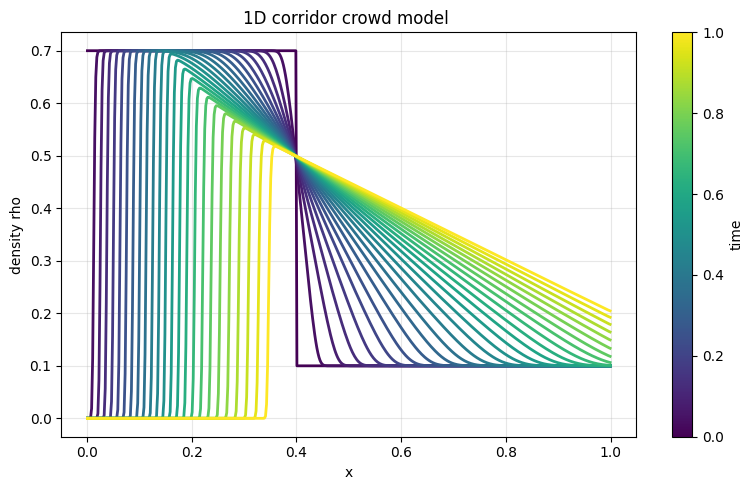

In [99]:
def initial_density_traffic(x):
    return np.where(x <= 0.4, 0.7, 0.1)

x_coords, density_snapshots = solve_lwr_corridor(
    initial_density_traffic,
    rho_left=0.0,
    rho_right=None,
    num_time_steps=1000,
    num_snapshots=25,
)

plot_density_snapshots(x_coords, density_snapshots, title="1D corridor crowd model ")

In [86]:
create_density_animation(x_coords, density_snapshots, filename="density_evolution.gif", title="1D corridor crowd model", fps=10)

Animation saved to density_evolution.gif


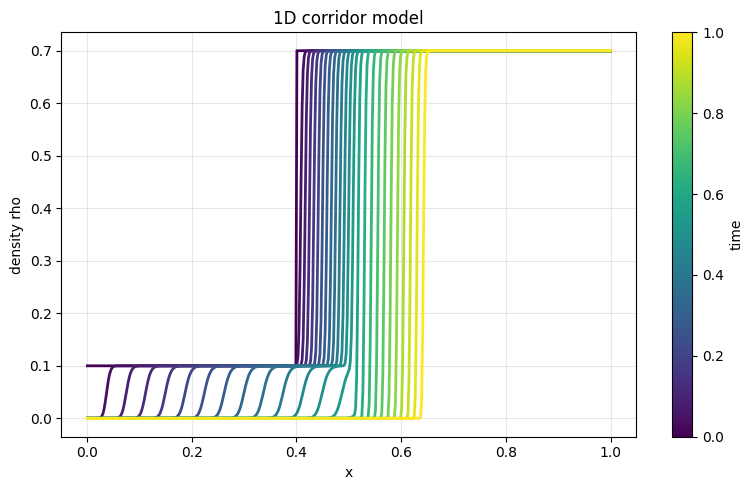

In [101]:
def initial_density_shock(x):
    return np.where(x <= 0.4, 0.1, 0.7)

x_coords, density_snapshots = solve_lwr_corridor(
    initial_density_shock,
    num_time_steps=1000,
    num_snapshots=25,
)

plot_density_snapshots(x_coords, density_snapshots, title="1D corridor model")

Schock type test

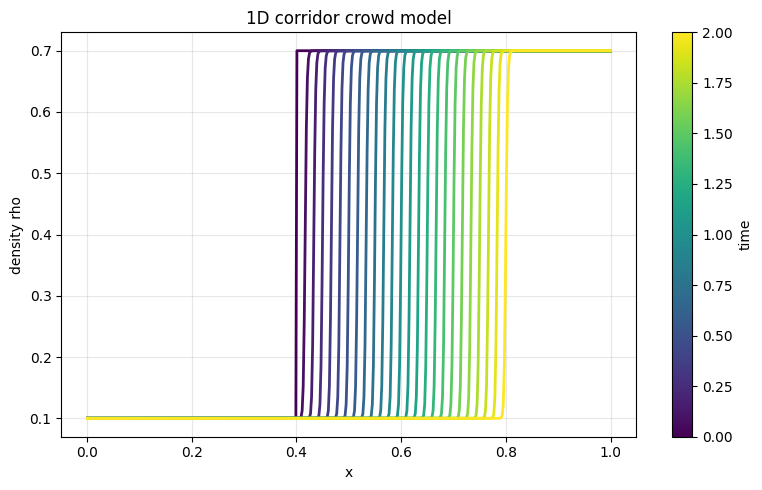

In [103]:
x_coords, density_snapshots = solve_lwr_corridor(
    initial_density_shock,
    T=2.0,
    rho_left=0.1,
    rho_right=0.7,
    num_time_steps=2000,
    num_snapshots=25,
)

plot_density_snapshots(x_coords, density_snapshots, title="1D corridor crowd model")

In [88]:
# gif
create_density_animation(x_coords, density_snapshots, filename="density_evolution.gif", title="1D corridor crowd model", fps=10)

Animation saved to density_evolution.gif
